In [89]:
import pandas as pd
import glob
import sys

dict_samples = { 'PanPan':'Bonobo', 'PanTro':'Chimpanzee', 'hprc':'Human', 
				 'GorGor':'Gorilla', 'PonAbe':'Sorang', 'PonPyg':'Borang' }

# chimp_subspecies = pd.read_table("../chimp_subspecies.tsv")[['Name','Subspecies fixed']].set_index('Name')['Subspecies fixed'].to_dict()
chimp_subspecies = {'PD_0427': '???',
 'Kopongo': 'P_T_E',
 'Tobi': 'P_T_E',
 'Damian': 'P_T_E',
 'Andromeda': 'P_T_S',
 'Harriet': 'P_T_S',
 'Nakuu': 'P_T_S',
 'Cleo': 'P_T_S',
 'Ikuru': 'P_T_S',
 'Athanga': 'P_T_S',
 'Brigitta': 'P_T_T',
 'Cindy_troglodytes': 'P_T_T',
 'Cindytroglodytes': 'P_T_T',
 'Lara': 'P_T_T',
 'Luky': 'P_T_T',
 'Mirinda': 'P_T_T',
 'Ula': 'P_T_T',
 'Gamin': 'P_T_T',
 'SeppToni': 'P_T_V',
 'Jimmie': 'P_T_V',
 'Bosco': 'P_T_V',
 'Koby': 'P_T_V'}

def get_matrix(sample):
	df = pd.read_table( f'combined_matrix.t2t_{sample}.tsv', dtype=str )
	df = df.replace({"1.0": "1", "0.0": "0"}) #make sure these are not saved as floats
	return df

def classify_values(s):
	if s != s:  # NaN check
		return 'NaN'
	ones = s.count('1')
	zeros = s.count('0')
	total = ones + zeros
	# Classifications.
	if zeros == 0:
		return 'Fixed' 	# Only 1s
	elif ones == 0:
		return 'Unique to ref' 	# Only 0s
	elif zeros == 1:
		return 'All but one' 	# Mostly 1s and one 0
	elif ones == 1:
		return 'Rare'	# Mostly 0s and one 1
	else:
		return 'Variable' 	# Mix of 1s and 0s
	
def get_species_specific(sample, quiet=False):
	# Get matrix, then species and assembly names.
	df = get_matrix(sample)
	species = dict_samples[sample]
	assembly = df['NUMT_ID'].str.split('_').str[0][0]
	if not quiet:
		print( f"# Number of '{assembly}' NUMTs:", df.shape[0])
		
	# Get the order of T2T columns in this matrix.
	t2t_cols = list(df.columns[1:7])
	if not quiet:
		print( f"# The order of T2T columns is:", t2t_cols)
	
	# Unit test: are these the correct and complete valeus for the T2T columns?
	if set(t2t_cols) != set(dict_samples.values()):
		raise ValueError('\n\t# The T2T species names are inconsistent with the dictionary values.' \
						 '\n\t# Perhaps the T2T columns are not selected properly.')
	
	# Concatenate values for T2T cols.
	df['Label'] = df[t2t_cols].astype(str).agg(''.join, axis=1)

	# Label for species-specific NUMTs (ss).
	label_ss = ''.join([ "1" if x == species else "0" for x in t2t_cols ])
	if not quiet:
		print( f"# The species-specific label for '{assembly}' ({species}) NUMTs is:", label_ss)

	# Use label to SS NUMTs.
	df_ss = df[df['Label']==label_ss]#.drop('Label', axis=1)
	if not quiet:
		print( f"# Number of '{assembly}' NUMTs that are species-specific:", df_ss.shape[0])
		print('\n')
	
	# Get the subset of columns for non-T2T population.
	subset_cols = list( set(df_ss.columns) - set(dict_samples.values()) - set(['NUMT_ID','Label']) )

	# Unit test: are these the correct number of non-T2T sample columns?
	if len(subset_cols) != len(df.columns) - len(t2t_cols) - len(['NUMT_ID', 'Label']):
		# Expected number of columns
		print( len(subset_cols), len(t2t_cols), len(['NUMT_ID', 'Label']), len(df.columns) )
		raise ValueError("\n\t# The number of sample columns is different than expected."\
				   		 f"\n\t# Verify the expression: {len(subset_cols)} + {len(t2t_cols)} + {len(['NUMT_ID', 'Label'])} = {len(df.columns)}")
	
	# Concatenate values for non-T2T population cols.
	df_ss = df_ss.copy()
	df_ss['Values'] = df_ss[subset_cols].astype(str).agg(''.join, axis=1)
	df_ss['Classification'] = df_ss['Values'].apply(classify_values)

	# Prepare output.
	df_ss['Assembly'] = assembly
	df_ss['Species'] = 'S. orangutan' if species == 'Sorang' else 'B. orangutan' if species == 'Borang' else species
	df_ss['Total_samples'] = len(subset_cols) + 1 	# Includes T2T
	df_values = df_ss[['Assembly', 'Species', 'NUMT_ID', 'Label', 'Values', 'Total_samples', 'Classification']]

	return df_values
	


df = get_species_specific('PanTro', quiet=True)
df

# Create summary of values.
summary = df.groupby('Species')['Classification'].value_counts().reset_index(name='Count')
summary['Total_samples'] = summary['Species'].map(df.groupby('Species')['Total_samples'].first())

# Specify order to match tree.
species_order = list(df['Species'].unique())
summary['Species'] = pd.Categorical(summary['Species'], categories=species_order, ordered=True)
summary = summary.sort_values(['Species', 'Classification']).reset_index(drop=True)

summary


,Species,Classification,Count,Total_samples
0,Chimpanzee,All but one,12,21
1,Chimpanzee,Fixed,19,21
2,Chimpanzee,Unique to ref,1,21
3,Chimpanzee,Variable,30,21


In [90]:
from collections import defaultdict

# Clearer version: summarize classifications of PanTro species-specific NUMTs by subspecies

mat = get_matrix('PanTro')

# Identify T2T columns and the PanTro species-specific label, then filter to those NUMTs
t2t_cols = list(mat.columns[1:7])
species = dict_samples['PanTro']
mat['Label'] = mat[t2t_cols].astype(str).agg(''.join, axis=1)
label_ss = ''.join("1" if s==species else "0" for s in t2t_cols)
df_ss = mat[mat['Label'] == label_ss].copy()

# Non-T2T sample columns to analyze
sample_cols = [col for col in df_ss.columns if col not in set(t2t_cols + ['NUMT_ID','Label'])]

# Group sample columns by subspecies using chimp_subspecies mapping
cols_by_sub = defaultdict(list)
for col in sample_cols:
	subs = chimp_subspecies.get(col)
	if subs:
		cols_by_sub[subs].append(col)

# For each subspecies, concatenate each NUMT's sample values, classify, and count classifications
records = []
for subspecies, cols in cols_by_sub.items():
	if not cols:
		continue
	concatenated = df_ss[cols].astype(str).agg(''.join, axis=1)     # one string per NUMT for these samples
	classifications = concatenated.apply(classify_values)          # classify each NUMT for this subspecies
	counts = classifications.value_counts()
	for cls, cnt in counts.items():
		records.append({
			'Subspecies': subspecies,
			'Classification': cls,
			'Count': int(cnt),
			'Total_samples': len(cols)
		})

# Build result DataFrame and order classifications for readability
order = ['Fixed','All but one','Rare','Variable','Unique to ref','NaN']
summary_subspecies = pd.DataFrame.from_records(records)
summary_subspecies['Classification'] = pd.Categorical(summary_subspecies['Classification'],
													 categories=order, ordered=True)
summary_subspecies = summary_subspecies.sort_values(['Subspecies','Classification']).reset_index(drop=True)

summary_subspecies

,Subspecies,Classification,Count,Total_samples
0,P_T_E,Fixed,57,3
1,P_T_E,All but one,2,3
2,P_T_E,Rare,1,3
3,P_T_E,Unique to ref,2,3
4,P_T_S,Fixed,48,5
5,P_T_S,All but one,8,5
6,P_T_S,Variable,5,5
7,P_T_S,Unique to ref,1,5
8,P_T_T,Fixed,20,7
9,P_T_T,All but one,12,7


Saved: subspecies_pie_charts.pdf, subspecies_pie_charts.png


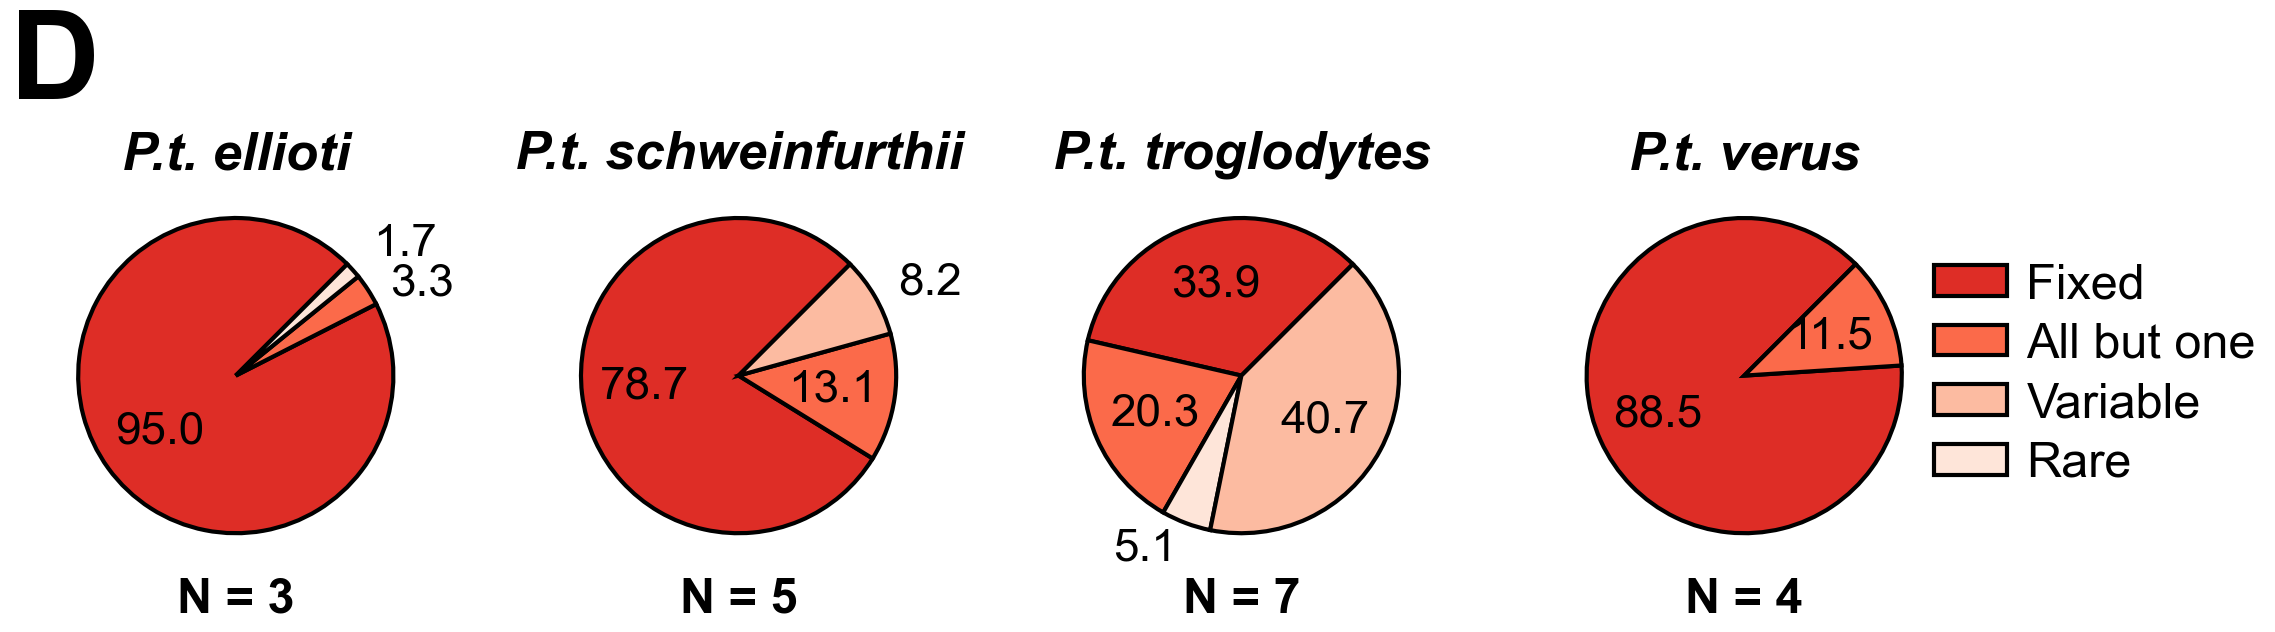

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# Filter out "Unique to ref" if present
summary_subspecies = summary_subspecies[summary_subspecies["Classification"] != "Unique to ref"]

title_size = 38
n_size = 35
legend_size = n_size
perc_size = n_size - 2
d_size = 90

palette = {
	"Fixed": '#de2d26',
	"All but one": "#fb6a4a",
	"Variable": "#fcbba1",
	"Unique to ref": "#fcbba1",
	"Rare": "#fee5d9",
}

subspecies_list = summary_subspecies["Subspecies"].unique()
n = len(subspecies_list)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)
axes = axes[0]
plt.subplots_adjust(wspace=0.1)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

for ax, subs in zip(axes, subspecies_list):
	data = summary_subspecies[summary_subspecies["Subspecies"] == subs].copy()
	colors = data["Classification"].map(palette).fillna("#999999")

	wedges, texts, autotexts = ax.pie(
		data["Count"],
		labels=None,
		colors=colors,
		autopct="%1.1f%%",
		startangle=45,
		wedgeprops={"edgecolor": "black", "linewidth": 3},
		textprops={"fontsize": perc_size},
	)

	# Move small percentage labels apart
	small_labels = [(i, w, t) for i, (w, t) in enumerate(zip(wedges, autotexts))
					if float(t.get_text().replace("%", "")) < 11]

	for j, (_, wedge, autotext) in enumerate(small_labels):
		angle = (wedge.theta1 + wedge.theta2) / 2
		x = np.cos(np.deg2rad(angle))
		y = np.sin(np.deg2rad(angle))

		y_offset = (j - (len(small_labels) - 1) / 2) * 0.1

		label_r = 1.17
		autotext.set_position((label_r * x, label_r * y + y_offset))
		autotext.set_ha("left" if x >= 0 else "right")
		autotext.set_va("center")
		autotext.set_color("black")

	for t in autotexts:
		t.set_text(t.get_text().replace("%", ""))
	ax.set_title(subs, fontsize=title_size, fontweight="bold")
	ax.text(0.5, -0.1, f"N = {data['Total_samples'].iloc[0]}", transform=ax.transAxes, ha="center", fontsize=n_size, fontweight="bold")

# Single legend for all subspecies (only classifications present)
present = set(summary_subspecies["Classification"].unique())
labels = [label for label in palette.keys() if label in present]

if labels:
	handles = [
		plt.Rectangle((0, 0), 1, 1, facecolor=palette[label], edgecolor="black", linewidth=3.0)
		for label in labels
	]
	fig.legend(
		handles,
		labels,
		loc="center right",
		bbox_to_anchor=(1.15, 0.5),
		frameon=False,
		fontsize=legend_size,
		handlelength=1.5,
		handleheight=0.6,
		handletextpad=0.4,
		borderpad=0.2,
		labelspacing=0.3,
	)

	fig.text(0.01, 1.23, "D", ha="left", va="top", fontsize=d_size, fontweight="bold")

plt.tight_layout()
out_pdf = "subspecies_pie_charts.pdf"
out_png = "subspecies_pie_charts.png"

title_map = {
	"P_T_E": "P.t. ellioti",
	"P_T_S": "P.t. schweinfurthii",
	"P_T_T": "P.t. troglodytes",
	"P_T_V": "P.t. verus",
}

for ax in axes:
	ax.set_title(title_map.get(ax.get_title(), ax.get_title()), fontsize=title_size, fontweight="bold", fontstyle="italic")
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight", dpi=300)
print(f"Saved: {out_pdf}, {out_png}")
plt.show()


In [95]:
# show raw concatenated values before classification, then show classification counts
for subspecies, cols in cols_by_sub.items():
	if not cols:
		continue
	concatenated = df_ss[cols].astype(str).agg(''.join, axis=1)
	print(f"Subspecies: {subspecies} (n_samples={len(cols)})")
	print("Raw concatenated value counts:")
	print(concatenated.value_counts())
	classifications = concatenated.apply(classify_values)
	print("Classification counts:")
	print(classifications.value_counts())
	print()

Subspecies: P_T_S (n_samples=5)
Raw concatenated value counts:
11111              45
11110               6
11000               4
nannannannannan     3
11010               1
11101               1
11011               1
00000               1
Name: count, dtype: int64
Classification counts:
Fixed            48
All but one       8
Variable          5
Unique to ref     1
Name: count, dtype: int64

Subspecies: P_T_T (n_samples=7)
Raw concatenated value counts:
1111111                  17
1111011                   6
0000000                   3
nannannannannannannan     3
1111101                   2
1110101                   2
1111010                   2
0111111                   1
1010001                   1
0100100                   1
0110101                   1
0010111                   1
1001100                   1
0111010                   1
0111101                   1
1101101                   1
0110001                   1
1011111                   1
1001110                   1
0000111   

In [82]:
# Predict subspecies for samples currently labeled P_T_T using non-P_T_T sample profiles.
# Uses existing variables: df_ss, cols_by_sub, chimp_subspecies, t2t_cols (if needed).

def _compute_centroid(sub, exclude=None):
	cols = [c for c in cols_by_sub.get(sub, []) if c in df_ss.columns and c != exclude]
	if len(cols) == 0:
		return pd.Series([pd.NA]*len(df_ss), index=df_ss.index)
	# convert to numeric (0/1), keep NaN
	mat = df_ss[cols].apply(pd.to_numeric, errors='coerce')
	mean = mat.mean(axis=1)  # fraction of 1s per NUMT
	# centroid: 1 if mean>=0.5, 0 if mean<0.5, NA if all NaN
	centroid = mean.where(~mean.isna()).apply(lambda x: '1' if x >= 0.5 else '0')
	centroid = centroid.reindex(df_ss.index).astype(object)
	centroid[mean.isna()] = pd.NA
	return centroid

def _similarity(individual, centroid):
	ind = df_ss[individual].astype(str).replace({'nan': pd.NA})
	valid = ind.notna() & centroid.notna()
	if valid.sum() == 0:
		return float('nan')
	return (ind[valid] == centroid[valid]).sum() / int(valid.sum())

# target individuals: those currently annotated as P_T_T
targets = [s for s, sub in chimp_subspecies.items() if sub == 'P_T_T' and s in df_ss.columns]
if len(targets) == 0:
	targets = cols_by_sub.get('P_T_T', [])

subs_list = list(cols_by_sub.keys())

# Precompute centroids per subspecies (we will recompute leave-one-out for the target's own subspecies)
centroids_cache = {sub: _compute_centroid(sub) for sub in subs_list}

rows = []
# normalize names to match df_ss columns (handle underscores like PD_0427 -> PD0427)
_col_map = {c.replace('_','').lower(): c for c in df_ss.columns}
targets = []
for s, sub in chimp_subspecies.items():
	if sub == 'P_T_T':
		if s in df_ss.columns:
			targets.append(s)
		else:
			k = s.replace('_','').lower()
			if k in _col_map:
				targets.append(_col_map[k])
# fallback if still empty
if len(targets) == 0:
	targets = cols_by_sub.get('P_T_T', [])
for ind in targets:
	scores = {}
	for sub in subs_list:
		# leave-one-out: if predicting for an individual that belongs to `sub`, exclude it from centroid
		if ind in cols_by_sub.get(sub, []):
			cent = _compute_centroid(sub, exclude=ind)
		else:
			cent = centroids_cache[sub]
		scores[sub] = _similarity(ind, cent)
	# best match
	best_sub = max(scores.items(), key=lambda x: (float('-inf') if pd.isna(x[1]) else x[1]))[0]
	rows.append({
		'Individual': ind,
		'Assigned_subspecies': chimp_subspecies.get(ind),
		'Predicted_subspecies': best_sub,
		'Predicted_score': scores[best_sub],
		**{f"score_{sub}": scores[sub] for sub in subs_list}
	})

pred_df = pd.DataFrame(rows).sort_values('Predicted_score', ascending=False).drop_duplicates().reset_index(drop=True)
pred_df

,Individual,Assigned_subspecies,Predicted_subspecies,Predicted_score,score_P_T_S,score_P_T_T,score_P_T_V,score_P_T_E
0,Lara,P_T_T,P_T_S,0.830508,0.830508,0.830508,0.762712,0.796610
1,Cindytroglodytes,P_T_T,P_T_S,0.813559,0.813559,0.813559,0.745763,0.779661
2,Luky,P_T_T,P_T_T,0.796610,0.711864,0.796610,0.677966,0.711864
3,Gamin,P_T_T,P_T_S,0.796610,0.796610,0.745763,0.762712,0.762712
4,Brigitta,P_T_T,P_T_T,0.745763,0.711864,0.745763,0.711864,0.745763
5,Ula,P_T_T,P_T_T,0.745763,0.728814,0.745763,0.661017,0.694915
6,Mirinda,P_T_T,P_T_S,0.694915,0.694915,0.661017,0.627119,0.627119


In [96]:
# Get variable NUMT IDs for subspecies P_T_T
cols = cols_by_sub.get('P_T_T', [])
concatenated = df_ss[cols].astype(str).agg(''.join, axis=1)
classifications = concatenated.apply(classify_values)
variable_numt_ids_ptt = df_ss.loc[classifications == 'Variable', 'NUMT_ID'].tolist()
variable_numt_ids_ptt

['mPanTro3_numt105',
 'mPanTro3_numt110',
 'mPanTro3_numt128',
 'mPanTro3_numt157',
 'mPanTro3_numt227',
 'mPanTro3_numt232',
 'mPanTro3_numt242',
 'mPanTro3_numt256',
 'mPanTro3_numt257',
 'mPanTro3_numt285',
 'mPanTro3_numt415',
 'mPanTro3_numt447',
 'mPanTro3_numt450',
 'mPanTro3_numt467',
 'mPanTro3_numt476',
 'mPanTro3_numt484',
 'mPanTro3_numt506',
 'mPanTro3_numt533',
 'mPanTro3_numt561',
 'mPanTro3_numt655',
 'mPanTro3_numt658',
 'mPanTro3_numt685',
 'mPanTro3_numt720',
 'mPanTro3_numt721']

In [108]:
variable_df = mat[mat['NUMT_ID'].isin(variable_numt_ids_ptt)].copy()

variable_by_subspecies = {
		sub: variable_df[['NUMT_ID'] + cols].copy()
		for sub, cols in cols_by_sub.items()
		if cols
}

# Classify each variable NUMT by subspecies
for sub, df_sub in variable_by_subspecies.items():
	concatenated = df_sub[cols_by_sub[sub]].astype(str).agg(''.join, axis=1)
	classifications = concatenated.apply(classify_values)
	variable_by_subspecies[sub] = df_sub.copy()
	variable_by_subspecies[sub]['Classification'] = classifications

# Combine per-subspecies 0/1 strings and classifications by NUMT for comparison
records = []
for sub, df_sub in variable_by_subspecies.items():
	if df_sub.empty:
		continue
	cols = [c for c in cols_by_sub.get(sub, []) if c in df_sub.columns]
	concatenated = df_sub[cols].astype(str).agg(''.join, axis=1)
	numt_ids = df_sub['NUMT_ID'] if 'NUMT_ID' in df_sub.columns else pd.Series(df_sub.index, index=df_sub.index)
	tmp = pd.DataFrame({
		'NUMT_ID': numt_ids.values,
		'Subspecies': sub,
		'Concatenated': concatenated.values,
		'Classification': df_sub['Classification'].values
	})
	records.append(tmp)

comparison = pd.concat(records, ignore_index=True)

# Wide-format: classifications and concatenated strings per subspecies
comparison_class_wide = comparison.pivot(index='NUMT_ID', columns='Subspecies', values='Classification')
comparison_vals_wide = comparison.pivot(index='NUMT_ID', columns='Subspecies', values='Concatenated')

comparison_wide = comparison_class_wide.join(comparison_vals_wide.add_prefix('vals_'))
# count unique classifications across subspecies
comparison_wide['n_unique_classifications'] = comparison_class_wide.nunique(axis=1)

comparison = comparison.sort_values(['NUMT_ID','Subspecies']).reset_index(drop=True)
comparison_wide = comparison_wide.sort_index()

# comparison
comparison_wide

Subspecies,P_T_E,P_T_S,P_T_T,P_T_V,vals_P_T_E,vals_P_T_S,vals_P_T_T,vals_P_T_V,n_unique_classifications
NUMT_ID,,,,,,,,,
mPanTro3_numt105,Fixed,Fixed,Variable,Fixed,111,11111,1110101,1111,2
mPanTro3_numt110,Fixed,Variable,Variable,Fixed,111,11000,1001001,1111,2
mPanTro3_numt128,Fixed,All but one,Variable,Fixed,111,11110,1110110,1111,3
mPanTro3_numt157,Fixed,Fixed,Variable,Fixed,111,11111,1110011,1111,2
mPanTro3_numt227,Rare,All but one,Variable,Fixed,010,11101,0000101,1111,4
mPanTro3_numt232,All but one,All but one,Variable,Fixed,011,11110,1111010,1111,3
mPanTro3_numt242,Fixed,Fixed,Variable,All but one,111,11111,1110101,1101,3
mPanTro3_numt256,Fixed,Fixed,Variable,All but one,111,11111,1000001,1011,3
mPanTro3_numt257,Fixed,Fixed,Variable,Fixed,111,11111,0111011,1111,2
